In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [65]:
# Read config file
config = load_config("conf.yaml")

# Choose results path
res_path = Path("results_0.5_Int")

# Read results
df_tot = pd.read_csv(res_path / f"df_tot.csv", index_col=0)


In [66]:
# Compute mean across repetitions
df_mean = df_tot.groupby(["size"], as_index=False).mean()
df_mean.head()

,size,idm_min,idm_max,idm_mean,mos_min,mos_max,mos_mean,mle
0,5,0.188975,0.630031,0.494150,0.146276,0.537957,0.392256,0.041054
1,10,0.190456,0.618017,0.478785,0.093277,0.532115,0.307998,0.026504
2,15,0.190560,0.650791,0.499792,0.092916,0.491010,0.310168,0.072452
3,20,0.150845,0.576943,0.365383,0.059251,0.397984,0.218597,0.041540
4,25,0.156913,0.608284,0.340406,0.055110,0.575938,0.204116,0.040342


In [67]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({

    # ---- base ----
    "figure.figsize": [7, 4], 
    "font.size": 9,

    # ---- axes ----
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",

    # ---- legend ----
    "legend.fontsize": 10,
    # "legend.labelspacing": 0.3,

    # ---- ticks ----
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # ---- lines ----
    "lines.linewidth": 1.0,

    # ---- dpi ----
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # # ---- tex ----
    # "text.usetex": True,
})

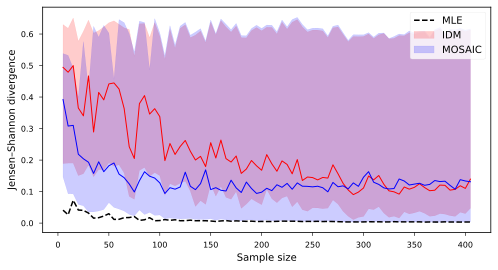

In [68]:
# Plot 
fig, ax = plt.subplots(1, 1)

ax.plot(df_mean["size"], df_mean["mle"], "--", linewidth=1.5, color="black", label="MLE")
ax.fill_between(df_mean["size"], df_mean["idm_min"], df_mean["idm_max"], color="red", alpha=.2, label="IDM")
ax.plot(df_mean["size"], df_mean["idm_mean"], color="red")
ax.fill_between(df_mean["size"], df_mean["mos_min"], df_mean["mos_max"], color="blue", alpha=.2, label="MOSAIC")
ax.plot(df_mean["size"], df_mean["mos_mean"], color="blue")


ax.set_xlabel("Sample size")
ax.set_ylabel("Jensen–Shannon divergence")
# ax.title(res_path)

ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Save figure
fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)